# IMDb Web Scraping Project

## Movie Rating, Popularity & Runtime Analysis

### Project Overview

This project focuses on collecting movie information from IMDb's Top 250 list using web scraping techniques.

The collected data is cleaned, transformed and analyzed to understand movie ratings, popularity, runtime and certification patterns.


### Project Workflow

Website Selection → Data Collection → Data Understanding → Data Cleaning → Exploratory Data Analysis → Data Visualization → Business Insights & Recommendations

In [1]:
import requests
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By

print("Libraries imported successfully!")

Libraries imported successfully!


# 1. Website Selection

### Selected Website
IMDb – Internet Movie Database

### Website URL
https://www.imdb.com/

### Data Source
IMDb Top 250 Movies

### Reason for Selection

IMDb provides useful movie information such as ranking, movie name, release year, rating, number of votes, runtime and certificate.

This makes the website suitable for analyzing movie popularity and rating patterns.

In [2]:
options = Options()
options.add_argument("--start-maximized")

driver = webdriver.Chrome(options=options)

url = "https://www.imdb.com/chart/top/"
driver.get(url)

print("IMDb Top 250 page opened successfully!")

IMDb Top 250 page opened successfully!


In [3]:
from selenium.webdriver.common.by import By

page_text = driver.find_element(By.TAG_NAME, "body").text

lines = page_text.splitlines()

print("Total lines collected:", len(lines))

Total lines collected: 1848


In [4]:
ranking_lines = [line for line in lines if line.startswith("#")]

print("Ranking lines found:", len(ranking_lines))
print(ranking_lines[:10])

Ranking lines found: 250
['#1', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10']


In [5]:
movie_names = []

for i in range(len(lines)):
    if lines[i].startswith("#"):
        movie_name = lines[i + 1]
        movie_names.append(movie_name)

print("Movies extracted:", len(movie_names))
print(movie_names[:10])

Movies extracted: 250
['The Shawshank Redemption', 'The Godfather', 'The Dark Knight', 'The Godfather Part II', 'The Lord of the Rings: The Return of the King', '12 Angry Men', "Schindler's List", 'The Lord of the Rings: The Fellowship of the Ring', 'Pulp Fiction', 'The Lord of the Rings: The Two Towers']


# 2. Data Collection

The IMDb Top 250 page was accessed using Selenium.

The following information is extracted from the page:

- Rank
- Movie Name
- Release Year
- Runtime
- Certificate
- IMDb Rating
- Number of Votes

In [6]:
movie_data = []

for i in range(len(lines)):
    if lines[i].startswith("#"):
        
        rank = lines[i].replace("#", "").strip()
        movie_name = lines[i + 1].strip()
        details = lines[i + 2].strip()
        rating_line = lines[i + 3].strip()

        # Extract year
        year_match = re.search(r"\b(19|20)\d{2}\b", details)
        year = year_match.group() if year_match else None

        # Extract runtime
        runtime_match = re.search(r"(\d+h\s*\d+m|\d+h|\d+m)", details)
        runtime = runtime_match.group() if runtime_match else None

        # Extract rating
        rating_match = re.search(r"\d+\.\d+", rating_line)
        rating = rating_match.group() if rating_match else None

        # Extract votes
        votes_match = re.search(r"\(([\d.,]+[KM]?)\)", rating_line)
        votes = votes_match.group(1) if votes_match else None

        # Extract certificate
        certificate = details

        if year:
            certificate = certificate.replace(year, "", 1)

        if runtime:
            certificate = certificate.replace(runtime, "", 1)

        certificate = certificate.strip()

        movie_data.append([
            rank,
            movie_name,
            year,
            runtime,
            certificate,
            rating,
            votes
        ])

df = pd.DataFrame(
    movie_data,
    columns=[
        "Rank",
        "Movie_Name",
        "Year",
        "Runtime",
        "Certificate",
        "Rating",
        "Votes"
    ]
)

print(df.head())
print("\nTotal movies:", len(df))

  Rank                                     Movie_Name  Year     Runtime  \
0    1                       The Shawshank Redemption  None  19942h 22m   
1    2                                  The Godfather  None  19722h 55m   
2    3                                The Dark Knight  None  20082h 32m   
3    4                          The Godfather Part II  None  19743h 22m   
4    5  The Lord of the Rings: The Return of the King  None  20033h 21m   

  Certificate Rating Votes  
0           R    9.3  None  
1           R    9.2  None  
2       PG-13    9.1  None  
3           R    9.0  None  
4       PG-13    9.0  None  

Total movies: 250


In [7]:
df.to_csv("imdb_raw_data.csv", index=False)

print("Raw dataset saved successfully!")

Raw dataset saved successfully!


# 3. Data Understanding

The scraped dataset contains movie information collected from the IMDb Top 250 list.

Before cleaning the data, the dataset is examined to understand its structure, columns, data types, missing values and duplicate records.

In [8]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Records:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (250, 7)

Column Names:
['Rank', 'Movie_Name', 'Year', 'Runtime', 'Certificate', 'Rating', 'Votes']

Data Types:
Rank           object
Movie_Name     object
Year           object
Runtime        object
Certificate    object
Rating         object
Votes          object
dtype: object

First 5 Records:


,Rank,Movie_Name,Year,Runtime,Certificate,Rating,Votes
0,1,The Shawshank Redemption,None,19942h 22m,R,9.3,None
1,2,The Godfather,None,19722h 55m,R,9.2,None
2,3,The Dark Knight,None,20082h 32m,PG-13,9.1,None
3,4,The Godfather Part II,None,19743h 22m,R,9.0,None
4,5,The Lord of the Rings: The Return of the King,None,20033h 21m,PG-13,9.0,None



Missing Values:
Rank             0
Movie_Name       0
Year           250
Runtime          0
Certificate      0
Rating           0
Votes          250
dtype: int64

Duplicate Rows: 0


# 4. Data Cleaning

The scraped data needs to be converted into a suitable format before analysis.

The following cleaning steps are performed:

- Convert Rank, Year and Rating into numeric values.
- Convert vote counts such as 3.2M into numbers.
- Convert movie runtime into minutes.
- Clean certificate values.
- Create a Decade column from the release year.
- Check missing and duplicate records.

In [9]:
df["Rank"] = pd.to_numeric(df["Rank"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

print("Numeric columns converted successfully!")

Numeric columns converted successfully!


In [10]:
def convert_votes(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().replace(",", "")

    if value.endswith("M"):
        return float(value[:-1]) * 1_000_000

    elif value.endswith("K"):
        return float(value[:-1]) * 1_000

    else:
        return float(value)

df["Votes"] = df["Votes"].apply(convert_votes)

print(df["Votes"].head())

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Votes, dtype: float64


In [11]:
runtime_values = []

for row in movie_data:
    runtime_text = str(row[3])

    # Remove year accidentally attached before runtime
    runtime_text = re.sub(r"^\d{4}", "", runtime_text).strip()

    match = re.search(r"(\d+h\s*\d+m|\d+h|\d+m)", runtime_text)

    if match:
        runtime = match.group(1)

        hours_match = re.search(r"(\d+)h", runtime)
        minutes_match = re.search(r"(\d+)m", runtime)

        hours = int(hours_match.group(1)) if hours_match else 0
        minutes = int(minutes_match.group(1)) if minutes_match else 0

        total_minutes = hours * 60 + minutes
    else:
        total_minutes = np.nan

    runtime_values.append(total_minutes)

df["Runtime_Minutes"] = runtime_values

print(df[["Movie_Name", "Runtime_Minutes"]].head(10))

                                          Movie_Name  Runtime_Minutes
0                           The Shawshank Redemption              142
1                                      The Godfather              175
2                                    The Dark Knight              152
3                              The Godfather Part II              202
4      The Lord of the Rings: The Return of the King              201
5                                       12 Angry Men               96
6                                   Schindler's List              196
7  The Lord of the Rings: The Fellowship of the Ring              178
8                                       Pulp Fiction              154
9              The Lord of the Rings: The Two Towers              179


In [12]:
def clean_certificate(value):
    value = str(value).strip()

    value = re.sub(r"^\d+h\s*\d*m", "", value)
    value = re.sub(r"^\d+h", "", value)
    value = re.sub(r"^\d+m", "", value)

    return value.strip()

df["Certificate"] = df["Certificate"].apply(clean_certificate)

df["Certificate"] = df["Certificate"].replace("", "Unknown")

print(df["Certificate"].value_counts())

Certificate
R            103
PG            38
PG-13         35
Not Rated     22
Approved      19
G             18
Unknown        6
Passed         6
Unrated        1
NC-17          1
TV-MA          1
Name: count, dtype: int64


In [13]:
def clean_certificate(value):
    value = str(value).strip()

    value = re.sub(r"^\d+h\s*\d*m", "", value)
    value = re.sub(r"^\d+h", "", value)
    value = re.sub(r"^\d+m", "", value)

    return value.strip()

df["Certificate"] = df["Certificate"].apply(clean_certificate)

df["Certificate"] = df["Certificate"].replace("", "Unknown")

print(df["Certificate"].value_counts())

Certificate
R            103
PG            38
PG-13         35
Not Rated     22
Approved      19
G             18
Unknown        6
Passed         6
Unrated        1
NC-17          1
TV-MA          1
Name: count, dtype: int64


In [14]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (250, 8)

Missing Values:
Rank                 0
Movie_Name           0
Year               250
Runtime              0
Certificate          0
Rating               0
Votes              250
Runtime_Minutes      0
dtype: int64

Duplicate Rows: 0

Data Types:
Rank                 int64
Movie_Name          object
Year               float64
Runtime             object
Certificate         object
Rating             float64
Votes              float64
Runtime_Minutes      int64
dtype: object


In [15]:
df.to_csv("imdb_cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# 5. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand patterns and relationships in the IMDb movie dataset.

The analysis focuses on:

- IMDb rating distribution
- Movies by release year
- Certificate distribution
- Rating and votes relationship
- Highest-rated movies
- Most-voted movies
- Longest movies
- Average rating by certificate
- Average rating by decade
- Movies by decade
- Rating and runtime relationship

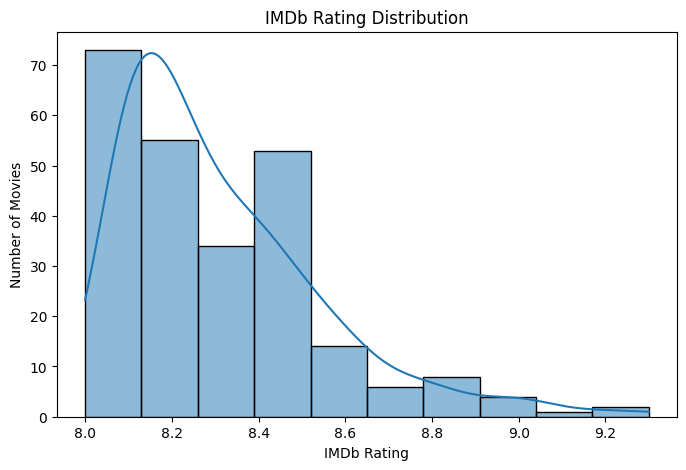

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Rating", bins=10, kde=True)

plt.title("IMDb Rating Distribution")
plt.xlabel("IMDb Rating")
plt.ylabel("Number of Movies")
plt.show()

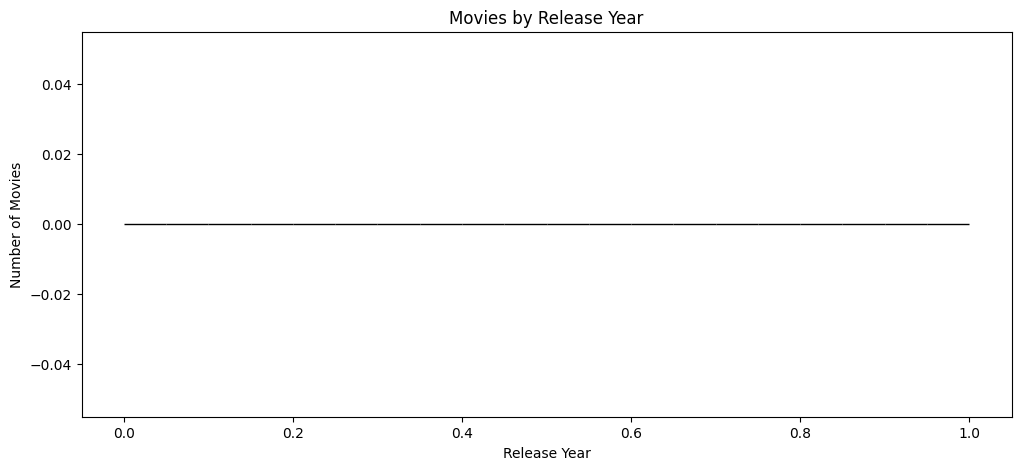

In [17]:
plt.figure(figsize=(12,5))

sns.histplot(data=df, x="Year", bins=20)

plt.title("Movies by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.show()

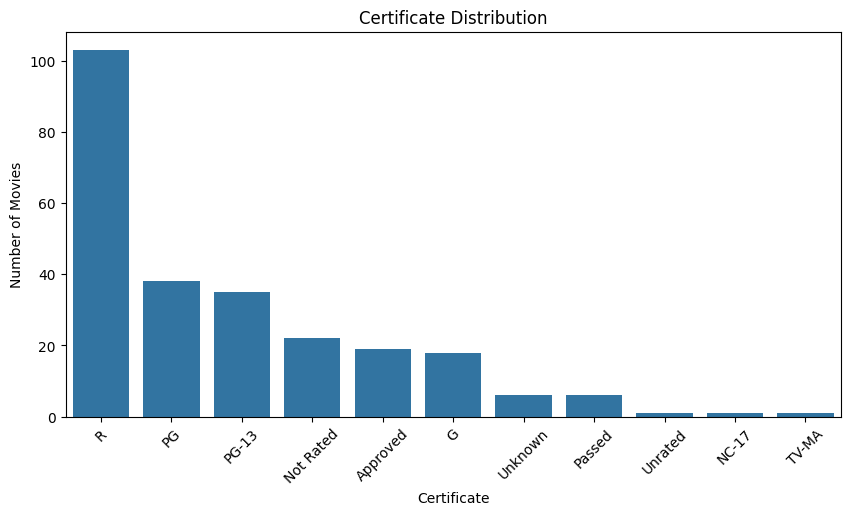

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Certificate", order=df["Certificate"].value_counts().index)

plt.title("Certificate Distribution")
plt.xlabel("Certificate")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

In [21]:
print(df[["Votes", "Rating"]].head())

print("\nData Types:")
print(df[["Votes", "Rating"]].dtypes)

print("\nMissing Values:")
print(df[["Votes", "Rating"]].isnull().sum())

   Votes  Rating
0    NaN     9.3
1    NaN     9.2
2    NaN     9.1
3    NaN     9.0
4    NaN     9.0

Data Types:
Votes     float64
Rating    float64
dtype: object

Missing Values:
Votes     250
Rating      0
dtype: int64


In [22]:
print(lines[:20])

['Menu', 'All', 'Watchlist', 'Sign in', 'EN', 'sponsored', 'IMDb CHARTS', 'Share', 'IMDb Top 250 movies', 'As rated by regular IMDb voters.', '0 OF 250 WATCHED', '0%', '250 Titles', 'Ranking', 'Ranking', 'IMDb rating', 'Release date', 'Number of ratings', 'Alphabetical', 'Popularity']


In [23]:
for i in range(20, 50):
    print(i, ":", lines[i])

20 : Runtime
21 : #1
22 : The Shawshank Redemption
23 : 19942h 22mR
24 : 9.3
25 :  (3.2M)
26 : Rate
27 : Mark as watched
28 : #2
29 : The Godfather
30 : 19722h 55mR
31 : 9.2
32 :  (2.3M)
33 : Rate
34 : Mark as watched
35 : #3
36 : The Dark Knight
37 : 20082h 32mPG-13
38 : 9.1
39 :  (3.2M)
40 : Rate
41 : Mark as watched
42 : #4
43 : The Godfather Part II
44 : 19743h 22mR
45 : 9.0
46 :  (1.5M)
47 : Rate
48 : Mark as watched
49 : #5


In [24]:
votes_values = []

for i in range(len(lines)):
    if lines[i].startswith("#"):
        vote_text = lines[i + 4].strip()
        vote_text = vote_text.replace("(", "").replace(")", "").strip()
        
        if "M" in vote_text:
            votes = float(vote_text.replace("M", "")) * 1000000
        elif "K" in vote_text:
            votes = float(vote_text.replace("K", "")) * 1000
        else:
            votes = float(vote_text)
        
        votes_values.append(votes)

df["Votes"] = votes_values

print(df[["Movie_Name", "Votes"]].head())

                                      Movie_Name      Votes
0                       The Shawshank Redemption  3200000.0
1                                  The Godfather  2300000.0
2                                The Dark Knight  3200000.0
3                          The Godfather Part II  1500000.0
4  The Lord of the Rings: The Return of the King  2200000.0


In [25]:
print(df["Votes"].isnull().sum())

0


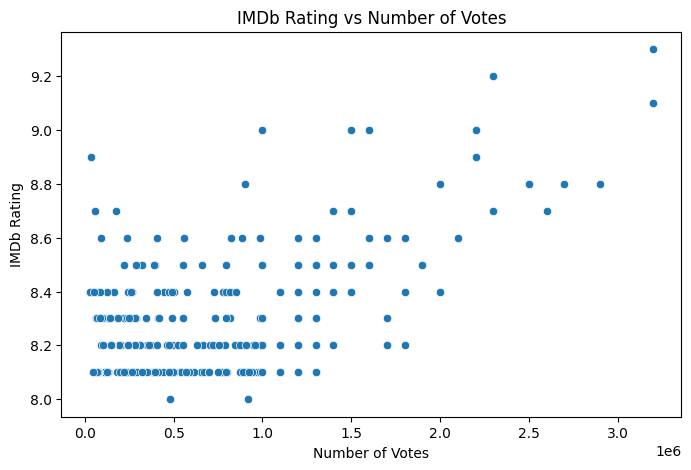

In [26]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Votes", y="Rating")

plt.title("IMDb Rating vs Number of Votes")
plt.xlabel("Number of Votes")
plt.ylabel("IMDb Rating")
plt.show()

In [27]:
top_rated = df.sort_values("Rating", ascending=False).head(10)

print(top_rated[["Movie_Name", "Rating"]])

                                           Movie_Name  Rating
0                            The Shawshank Redemption     9.3
1                                       The Godfather     9.2
2                                     The Dark Knight     9.1
3                               The Godfather Part II     9.0
4       The Lord of the Rings: The Return of the King     9.0
5                                        12 Angry Men     9.0
6                                    Schindler's List     9.0
7   The Lord of the Rings: The Fellowship of the Ring     8.9
92                   Attack on Titan: The Last Attack     8.9
8                                        Pulp Fiction     8.8


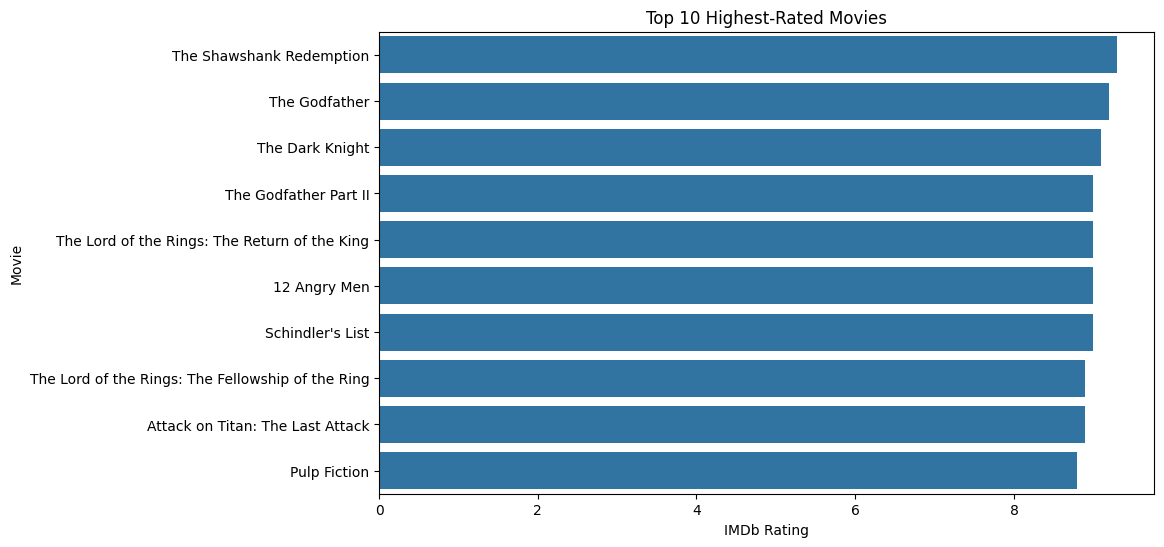

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_rated,
    x="Rating",
    y="Movie_Name"
)

plt.title("Top 10 Highest-Rated Movies")
plt.xlabel("IMDb Rating")
plt.ylabel("Movie")
plt.show()

In [29]:
most_voted = df.sort_values("Votes", ascending=False).head(10)

print(most_voted[["Movie_Name", "Votes"]])

                                           Movie_Name      Votes
0                            The Shawshank Redemption  3200000.0
2                                     The Dark Knight  3200000.0
13                                          Inception  2900000.0
12                                         Fight Club  2700000.0
16                                       Interstellar  2600000.0
8                                        Pulp Fiction  2500000.0
11                                       Forrest Gump  2500000.0
1                                       The Godfather  2300000.0
15                                         The Matrix  2300000.0
7   The Lord of the Rings: The Fellowship of the Ring  2200000.0


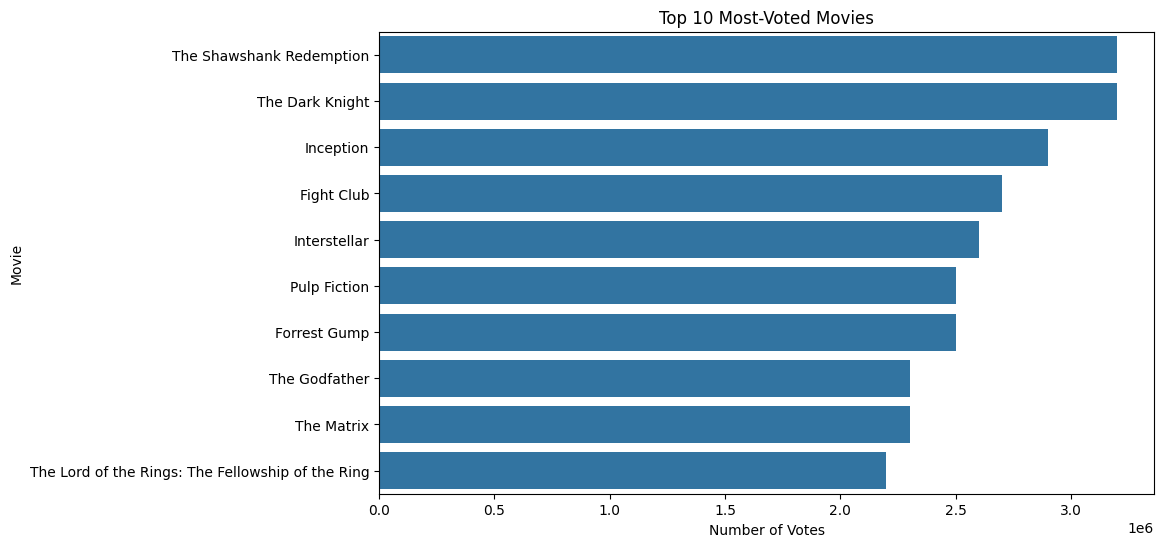

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=most_voted,
    x="Votes",
    y="Movie_Name"
)

plt.title("Top 10 Most-Voted Movies")
plt.xlabel("Number of Votes")
plt.ylabel("Movie")
plt.show()

In [31]:
certificate_rating = df.groupby("Certificate")["Rating"].mean().sort_values(ascending=False)

print(certificate_rating)

Certificate
Unrated      8.700000
TV-MA        8.600000
Unknown      8.500000
PG-13        8.377143
R            8.329126
NC-17        8.300000
PG           8.276316
Approved     8.268421
G            8.255556
Not Rated    8.250000
Passed       8.166667
Name: Rating, dtype: float64


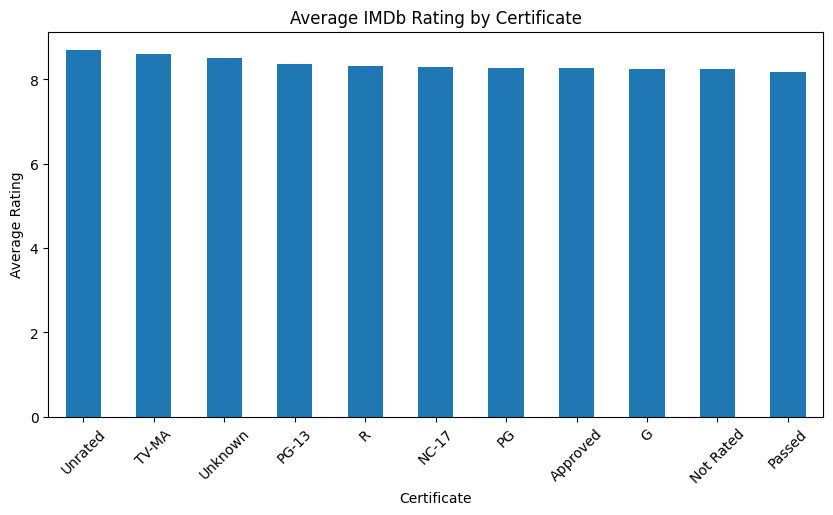

In [32]:
plt.figure(figsize=(10,5))

certificate_rating.plot(kind="bar")

plt.title("Average IMDb Rating by Certificate")
plt.xlabel("Certificate")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

In [34]:
df["Decade"] = (df["Year"] // 10) * 10

print(df[["Year", "Decade"]].head())

   Year  Decade
0   NaN     NaN
1   NaN     NaN
2   NaN     NaN
3   NaN     NaN
4   NaN     NaN


In [35]:
decade_counts = df["Decade"].value_counts().sort_index()

print(decade_counts)

Series([], Name: count, dtype: int64)


In [36]:
print(df[["Movie_Name", "Year"]].head(10))

print("\nYear data type:")
print(df["Year"].dtype)

print("\nMissing Year values:")
print(df["Year"].isnull().sum())

                                          Movie_Name  Year
0                           The Shawshank Redemption   NaN
1                                      The Godfather   NaN
2                                    The Dark Knight   NaN
3                              The Godfather Part II   NaN
4      The Lord of the Rings: The Return of the King   NaN
5                                       12 Angry Men   NaN
6                                   Schindler's List   NaN
7  The Lord of the Rings: The Fellowship of the Ring   NaN
8                                       Pulp Fiction   NaN
9              The Lord of the Rings: The Two Towers   NaN

Year data type:
float64

Missing Year values:
250


In [37]:
year_values = []

for i in range(len(lines)):
    if lines[i].startswith("#"):
        details = lines[i + 2].strip()
        year = int(details[:4])
        year_values.append(year)

df["Year"] = year_values

print(df[["Movie_Name", "Year"]].head(10))

                                          Movie_Name  Year
0                           The Shawshank Redemption  1994
1                                      The Godfather  1972
2                                    The Dark Knight  2008
3                              The Godfather Part II  1974
4      The Lord of the Rings: The Return of the King  2003
5                                       12 Angry Men  1957
6                                   Schindler's List  1993
7  The Lord of the Rings: The Fellowship of the Ring  2001
8                                       Pulp Fiction  1994
9              The Lord of the Rings: The Two Towers  2002


In [38]:
print("Missing Year values:", df["Year"].isnull().sum())

Missing Year values: 0


In [39]:
df["Decade"] = (df["Year"] // 10) * 10

print(df[["Year", "Decade"]].head(10))

   Year  Decade
0  1994    1990
1  1972    1970
2  2008    2000
3  1974    1970
4  2003    2000
5  1957    1950
6  1993    1990
7  2001    2000
8  1994    1990
9  2002    2000


In [40]:
decade_counts = df["Decade"].value_counts().sort_index()

print(decade_counts)

Decade
1920     6
1930     6
1940     9
1950    21
1960    17
1970    18
1980    26
1990    39
2000    48
2010    43
2020    17
Name: count, dtype: int64


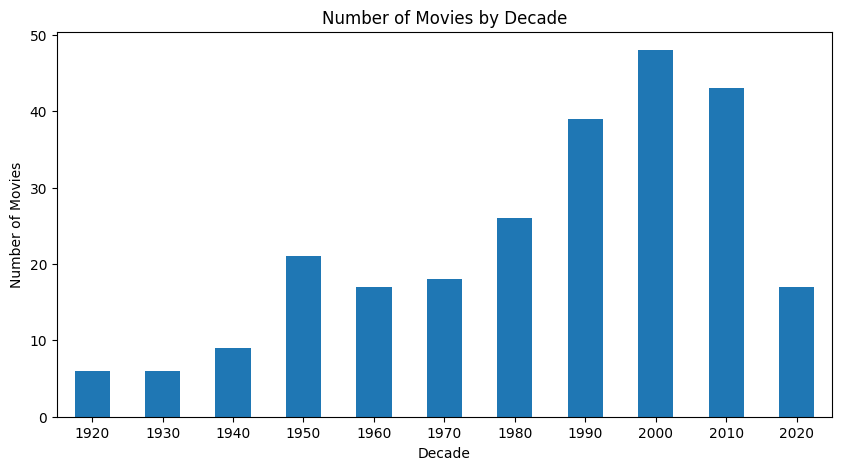

In [41]:
plt.figure(figsize=(10,5))

decade_counts.plot(kind="bar")

plt.title("Number of Movies by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.xticks(rotation=0)
plt.show()

In [42]:
decade_rating = df.groupby("Decade")["Rating"].mean().sort_index()

print(decade_rating)

Decade
1920    8.133333
1930    8.283333
1940    8.288889
1950    8.261905
1960    8.335294
1970    8.333333
1980    8.273077
1990    8.410256
2000    8.320833
2010    8.267442
2020    8.358824
Name: Rating, dtype: float64


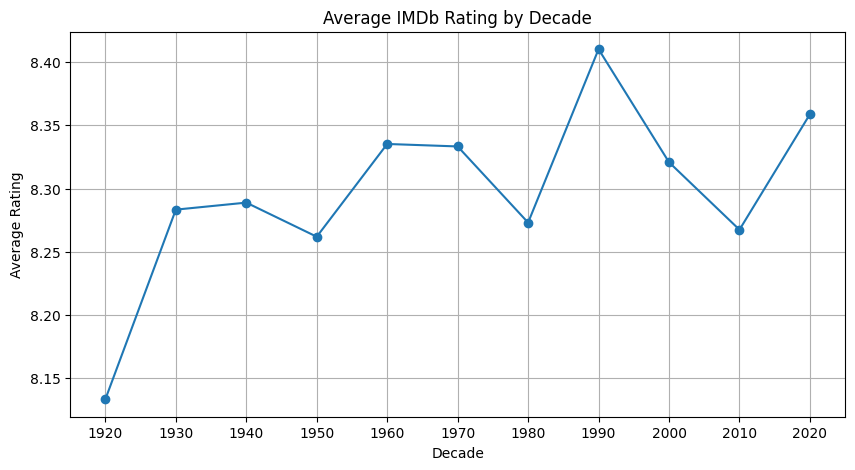

In [43]:
plt.figure(figsize=(10,5))

decade_rating.plot(kind="line", marker="o")

plt.title("Average IMDb Rating by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Rating")
plt.xticks(decade_rating.index)
plt.grid(True)
plt.show()

In [44]:
print("Average Runtime:", df["Runtime_Minutes"].mean(), "minutes")

longest_movie = df.loc[df["Runtime_Minutes"].idxmax()]

print("\nLongest Movie:")
print(longest_movie[["Movie_Name", "Runtime_Minutes"]])

Average Runtime: 131.612 minutes

Longest Movie:
Movie_Name         The Best of Youth
Runtime_Minutes                  374
Name: 175, dtype: object


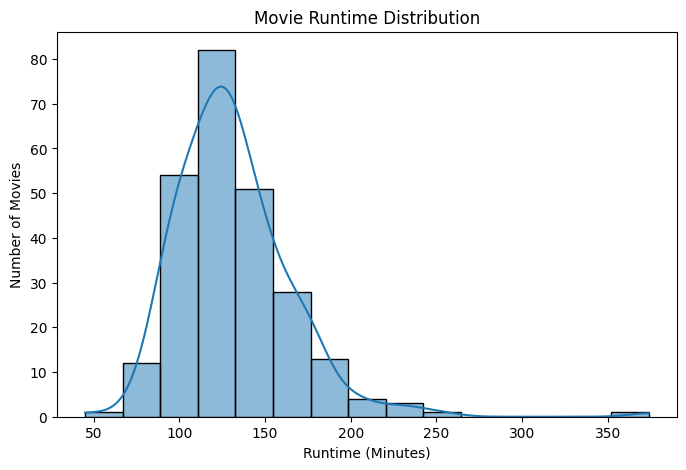

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Runtime_Minutes", bins=15, kde=True)

plt.title("Movie Runtime Distribution")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("Number of Movies")
plt.show()

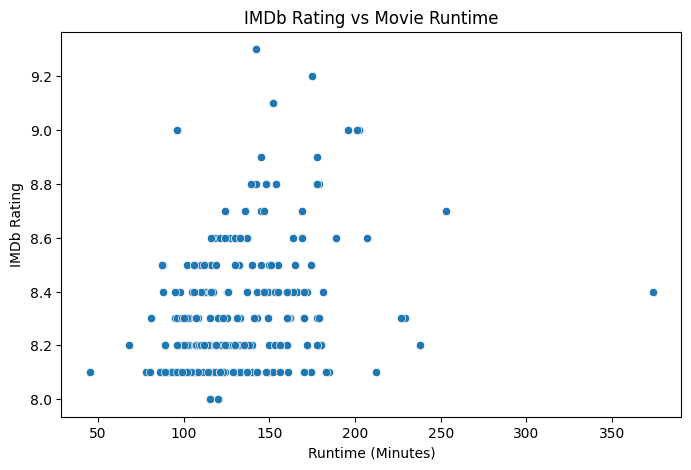

In [46]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Runtime_Minutes", y="Rating")

plt.title("IMDb Rating vs Movie Runtime")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("IMDb Rating")
plt.show()

In [47]:
correlation = df["Runtime_Minutes"].corr(df["Rating"])

print("Correlation between Runtime and Rating:", round(correlation, 2))

Correlation between Runtime and Rating: 0.3


# 6. EDA Summary

The Exploratory Data Analysis helped identify important patterns in the IMDb Top 250 dataset.

### Key observations

- The IMDb ratings are concentrated around the higher rating range.
- The dataset contains movies from different release years and decades.
- R is the most common movie certificate in the dataset.
- The Shawshank Redemption has the highest IMDb rating.
- The most-voted movies have received millions of user ratings.
- Movies have a wide range of runtimes, from shorter films to very long movies.
- The relationship between movie runtime and IMDb rating is also analyzed using correlation.
- The analysis shows how movie popularity, ratings, runtime and release period can be studied using data.

# 7. Business Insights & Recommendations

## Key Business Insights

1. IMDb ratings in the Top 250 dataset are generally high, showing that the dataset represents highly rated movies.

2. The Shawshank Redemption has the highest IMDb rating of 9.3 in the collected dataset.

3. The Shawshank Redemption also has one of the highest numbers of votes, showing strong audience engagement.

4. R is the most common certificate among the collected movies.

5. Movies from different decades are represented in the IMDb Top 250, with the 2000s having strong representation.

6. Movie runtime varies considerably across the dataset, including both shorter and very long movies.

7. The relationship between ratings and votes shows how audience engagement can be compared with movie ratings.

8. The relationship between runtime and rating was also analyzed to understand whether longer movies tend to receive higher ratings.

## Recommendations

- Movie platforms can use ratings and number of votes together to understand both movie quality and audience popularity.
- Movie recommendations can consider rating, popularity, certificate and runtime.
- Popularity trends across decades can help identify periods with strong representation in highly rated movies.
- Runtime analysis can help platforms provide movie recommendations based on users' preferred viewing duration.

# 8. Conclusion

This project demonstrated the complete process of collecting and analyzing movie data from IMDb.

Using Selenium, movie information was collected from the IMDb Top 250 page. The data was then cleaned and transformed using Python and Pandas.

Exploratory Data Analysis was performed using Pandas, Matplotlib and Seaborn to understand movie ratings, votes, certificates, release years, decades and runtime.

The project helped demonstrate how web scraping and data analysis can be combined to convert raw web data into meaningful insights.

In [48]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (250, 9)

Columns:
['Rank', 'Movie_Name', 'Year', 'Runtime', 'Certificate', 'Rating', 'Votes', 'Runtime_Minutes', 'Decade']

Missing Values:
Rank               0
Movie_Name         0
Year               0
Runtime            0
Certificate        0
Rating             0
Votes              0
Runtime_Minutes    0
Decade             0
dtype: int64

Duplicate Rows:
0

First 5 Rows:


,Rank,Movie_Name,Year,Runtime,Certificate,Rating,Votes,Runtime_Minutes,Decade
0,1,The Shawshank Redemption,1994,19942h 22m,R,9.3,3200000.0,142,1990
1,2,The Godfather,1972,19722h 55m,R,9.2,2300000.0,175,1970
2,3,The Dark Knight,2008,20082h 32m,PG-13,9.1,3200000.0,152,2000
3,4,The Godfather Part II,1974,19743h 22m,R,9.0,1500000.0,202,1970
4,5,The Lord of the Rings: The Return of the King,2003,20033h 21m,PG-13,9.0,2200000.0,201,2000


In [51]:
df.to_csv("imdb_cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [52]:
import os

print(os.path.exists("imdb_cleaned_data.csv"))

True
